

# Project NTI — Cars Data: Cleaning, EDA & Gradient Boosting Regression




In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline


In [137]:
df = pd.read_csv('cars_data (1).csv')
df.head()


,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2.0,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5.0,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1.0,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1.0,6451.0


In [138]:
df.columns

Index(['Brand', 'Year', 'Mileage', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Previous_Owners', 'Price'],
      dtype='object')

In [139]:
df.shape

(1000, 8)

In [140]:
df.dtypes

,0
Brand,object
Year,float64
Mileage,float64
Engine_Size,float64
Fuel_Type,object
Transmission,object
Previous_Owners,float64
Price,float64


In [141]:
for value in (df.columns):
  print(value)

Brand
Year
Mileage
Engine_Size
Fuel_Type
Transmission
Previous_Owners
Price


In [142]:
for i, v in enumerate(df.columns):
    print(i, v)

0 Brand
1 Year
2 Mileage
3 Engine_Size
4 Fuel_Type
5 Transmission
6 Previous_Owners
7 Price


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            979 non-null    object 
 1   Year             974 non-null    float64
 2   Mileage          979 non-null    float64
 3   Engine_Size      964 non-null    float64
 4   Fuel_Type        982 non-null    object 
 5   Transmission     962 non-null    object 
 6   Previous_Owners  949 non-null    float64
 7   Price            987 non-null    float64
dtypes: float64(5), object(3)
memory usage: 62.6+ KB


In [144]:
df.head()


,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2.0,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5.0,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1.0,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1.0,6451.0


In [145]:
df.columns = df.columns.str.strip().str.lower()

In [146]:
print(df.columns.tolist())

['brand', 'year', 'mileage', 'engine_size', 'fuel_type', 'transmission', 'previous_owners', 'price']


In [147]:
df['previous_owners'].isna().sum()

np.int64(51)

In [148]:
df.isna().sum()

,0
brand,21
year,26
mileage,21
engine_size,36
fuel_type,18
transmission,38
previous_owners,51
price,13


In [149]:
df.duplicated().sum()

np.int64(0)

In [150]:
df.drop_duplicates(inplace = True)

In [151]:
new_labels = ['brand', 'year', 'mileage', 'engine_size', 'fuel_type', 'transmission', 'previous_owners', 'price']

In [152]:
df.duplicated().sum()

np.int64(0)

In [153]:
for v in (df.columns):
    print(v)

brand
year
mileage
engine_size
fuel_type
transmission
previous_owners
price


In [154]:
df.head()

,brand,year,mileage,engine_size,fuel_type,transmission,previous_owners,price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2.0,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5.0,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1.0,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1.0,6451.0


In [155]:
numeric_cols = ['year', 'mileage', 'engine_size', 'previous_owners']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
categorical_cols = ['brand', 'fuel_type', 'transmission']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df.dropna(subset=['price'], inplace=True)

In [156]:
df.isna().sum()

,0
brand,0
year,0
mileage,0
engine_size,0
fuel_type,0
transmission,0
previous_owners,0
price,0


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 987 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            987 non-null    object 
 1   year             987 non-null    float64
 2   mileage          987 non-null    float64
 3   engine_size      987 non-null    float64
 4   fuel_type        987 non-null    object 
 5   transmission     987 non-null    object 
 6   previous_owners  987 non-null    float64
 7   price            987 non-null    float64
dtypes: float64(5), object(3)
memory usage: 69.4+ KB


In [158]:
df.to_csv('cars_data (2).csv', index=False)

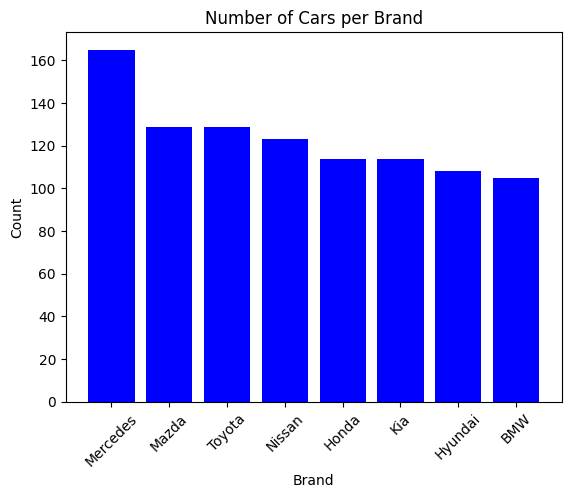

In [159]:
brand_counts = df['brand'].value_counts()
plt.bar(brand_counts.index, brand_counts.values, color='blue')
plt.title('Number of Cars per Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

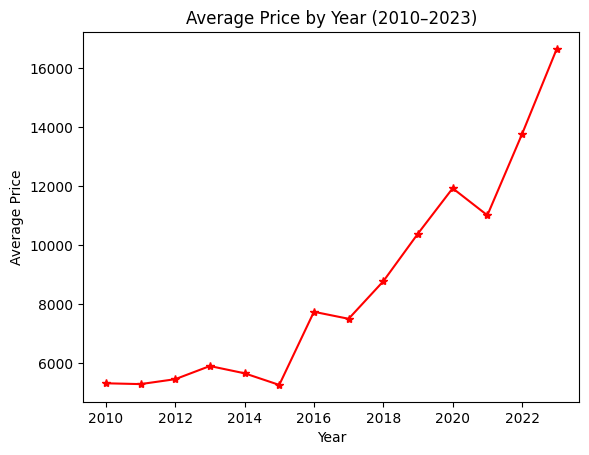

In [160]:
avg_price_by_year = df.groupby('year')['price'].mean()

plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker='*', color='red')
plt.title(f'Average Price by Year ({int(df["year"].min())}–{int(df["year"].max())})')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.show()


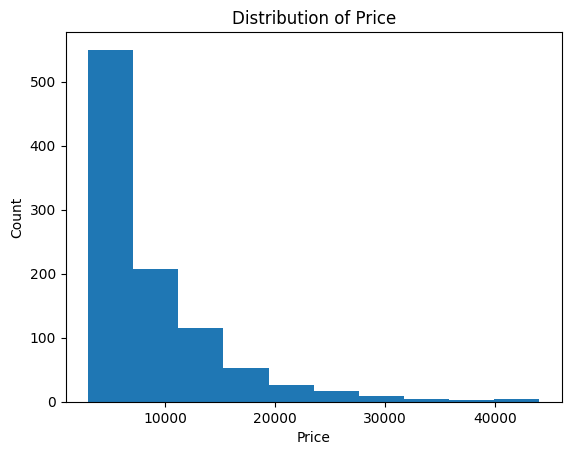

In [161]:
plt.hist(df['price']);
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

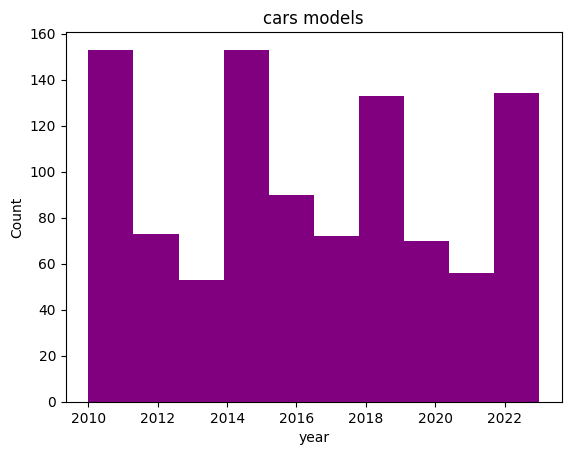

In [162]:
plt.hist(df['year'],color='purple');
plt.title('cars models')
plt.xlabel('year')
plt.ylabel('Count')
plt.show()

## Gradient Boosting Regression



### Step 1: Encode categorical columns into dummy variables


In [163]:

df_enc = pd.get_dummies(df, columns=['brand', 'fuel_type', 'transmission'], drop_first=True)
df_enc.head()



,year,mileage,engine_size,previous_owners,price,brand_Honda,brand_Hyundai,brand_Kia,brand_Mazda,brand_Mercedes,brand_Nissan,brand_Toyota,fuel_type_Electric,fuel_type_Hybrid,fuel_type_Petrol,transmission_Manual
0,2015.0,110373.0,2.5,2.0,3000.0,False,False,True,False,False,False,False,True,False,False,True
1,2010.0,186144.0,1.3,5.0,4844.0,False,False,False,False,True,False,False,True,False,False,True
2,2018.0,29574.0,2.6,1.0,6628.0,False,False,False,False,False,True,False,False,False,True,True
3,2010.0,139502.0,2.4,3.0,3000.0,False,False,True,False,False,False,False,False,False,False,False
4,2014.0,148748.0,3.5,1.0,6451.0,False,False,False,False,False,False,False,False,False,False,True


### Step 2: Extract the input (all features) and output (price) variables


In [164]:
X = df_enc.drop(columns=['price']).values
y = df_enc['price'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")



X shape: (987, 15), y shape: (987,)


### Step 3: Split the data into train and test data


In [165]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")



X_train: (789, 15), X_test: (198, 15)


### Step 4: Create and train the Gradient Boosting Regression model


In [166]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=0
)
gb_reg.fit(X_train, y_train)



GradientBoostingRegressor(n_estimators=300, random_state=0)

### Predict on the test set and evaluate the model


In [167]:
y_pred = gb_reg.predict(X_test)

from sklearn.metrics import r2_score
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")


R2 Score: 0.8175
